In [7]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Unvaccinated children with starting point

In [2]:
with open('5_Scenario_results_with_initial_conditions.json') as json_file:
    F_results = json.load(json_file)


In [3]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["S["]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [4]:
grouped_results

{'S[': [{'S[PCV,2,4]': 190880008.0990983},
  {'S[Hib,8,3]': 0.0},
  {'S[PCV,6,4]': 0.0},
  {'S[Hib,7,5]': 0.0},
  {'S[Rotavirus,8,2]': 0.0},
  {'S[Rotavirus,0,1]': 14250000.0},
  {'S[Rotavirus,1,1]': 0.0},
  {'S[Polio,5,3]': 0.0},
  {'S[Measles,6,5]': 0.0},
  {'S[Pertussis,6,4]': 0.0},
  {'S[Pertussis,2,5]': 0.0},
  {'S[Rotavirus,10,3]': 0.0},
  {'S[PCV,2,2]': 188404236.0290017},
  {'S[Tetanus,4,2]': 0.0},
  {'S[Rotavirus,0,3]': 14250000.0},
  {'S[PCV,4,3]': 0.0},
  {'S[HPV,3,5]': 0.0},
  {'S[Hepatitis_B,9,3]': 0.0},
  {'S[Tetanus,9,2]': 0.0},
  {'S[PCV,3,1]': 330101966.13147795},
  {'S[Hepatitis_B,4,4]': 0.0},
  {'S[Pertussis,6,2]': 0.0},
  {'S[Hepatitis_B,0,2]': 3123000.0},
  {'S[Diphtheria,7,2]': 0.0},
  {'S[Rotavirus,3,5]': 0.0},
  {'S[Measles,5,5]': 0.0},
  {'S[Pertussis,1,5]': 0.0},
  {'S[Pertussis,0,4]': 3207000.0},
  {'S[Measles,1,3]': 0.0},
  {'S[Polio,7,5]': 0.0},
  {'S[Tetanus,3,3]': 0.0},
  {'S[Diphtheria,1,3]': 0.0},
  {'S[HPV,5,3]': 0.0},
  {'S[Polio,8,3]': 0.0},
  {'S[Pe

In [5]:
# Extracting data into lists
antigen_list = []
year_list = []
value_list = []
scenario_list = []

for item in grouped_results['S[']:
    for key, value in item.items():
        # Splitting the key and extracting Antigen, Year, and Scenario
        parts = key.split(',')[0][2:], int(key.split(',')[1]), int(key.split(',')[2][:-1])
        
        # Appending values to lists
        antigen_list.append(parts[0])
        year_list.append(parts[1])
        scenario_list.append(parts[2])
        value_list.append(value)

# Creating a DataFrame
df = pd.DataFrame({
    'Antigen': antigen_list,
    'Year': year_list,
    'Value': value_list,
    'Scenario': scenario_list
})

# Displaying the DataFrame
print(df)


       Antigen  Year         Value  Scenario
0          PCV     2  1.908800e+08         4
1          Hib     8  0.000000e+00         3
2          PCV     6  0.000000e+00         4
3          Hib     7  0.000000e+00         5
4    Rotavirus     8  0.000000e+00         2
..         ...   ...           ...       ...
655        HPV    10  0.000000e+00         4
656        PCV     9  0.000000e+00         2
657    Measles     3  0.000000e+00         1
658        Hib     2  0.000000e+00         2
659  Rotavirus     1  0.000000e+00         4

[660 rows x 4 columns]


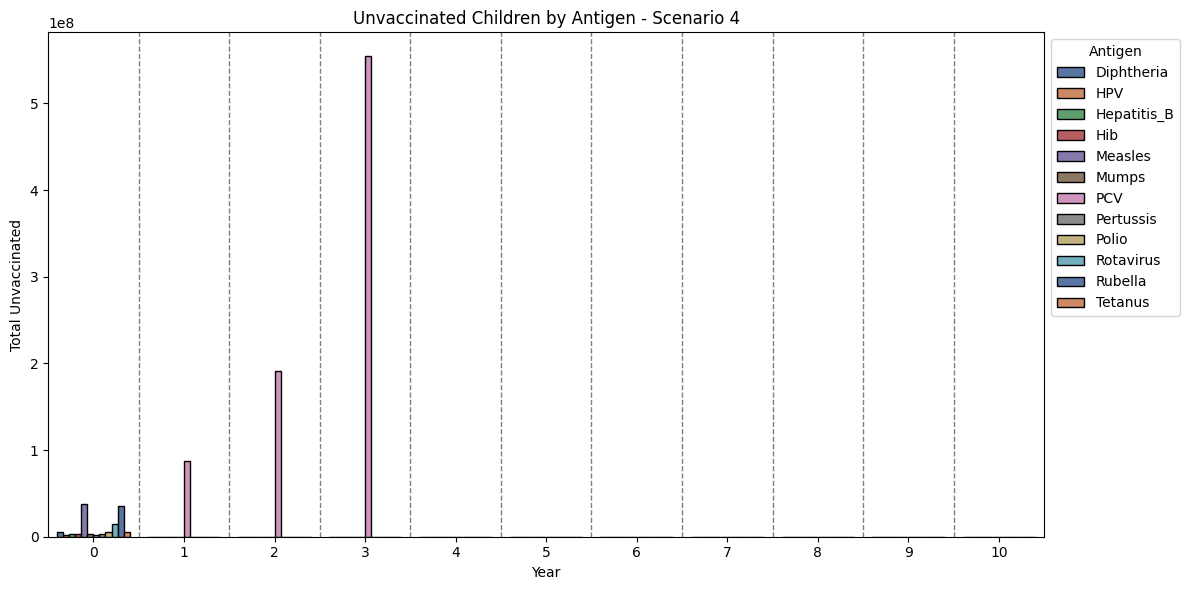

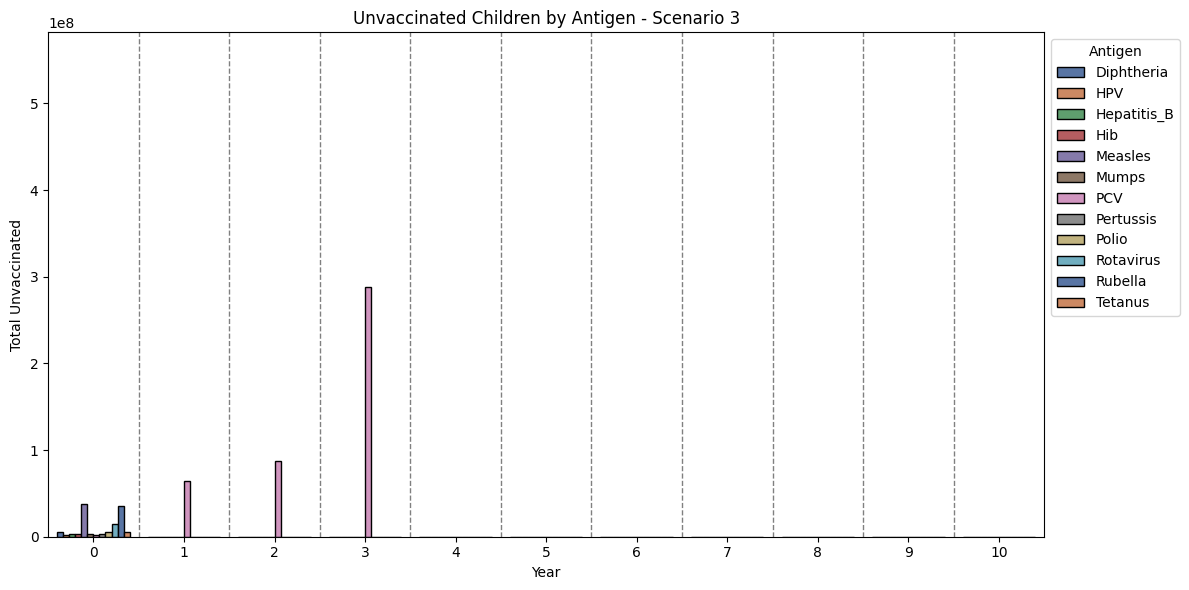

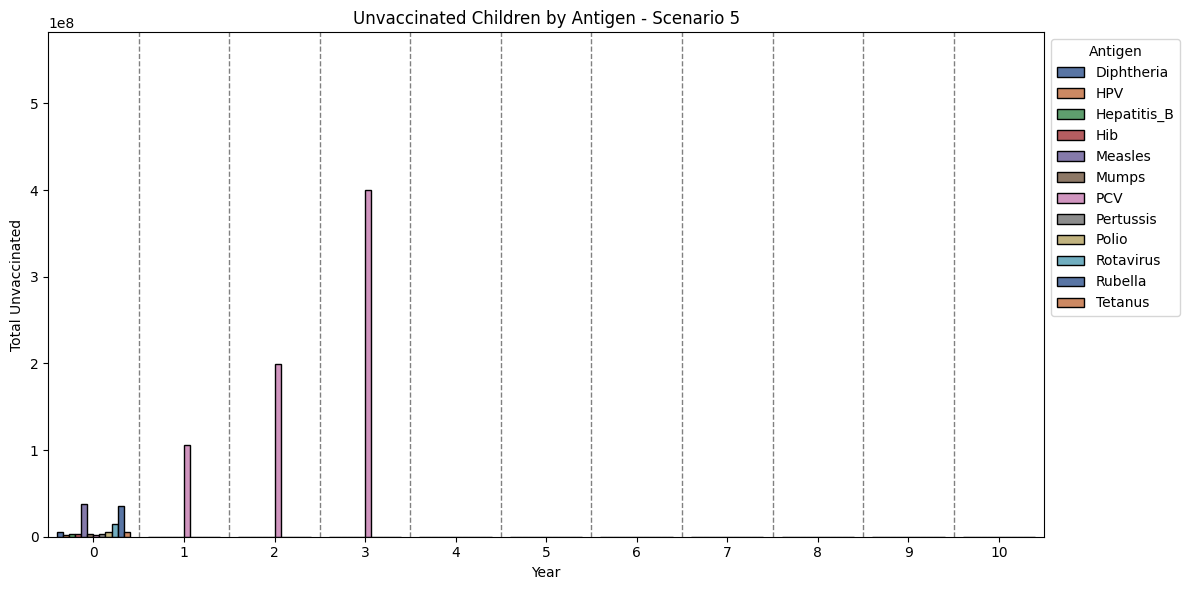

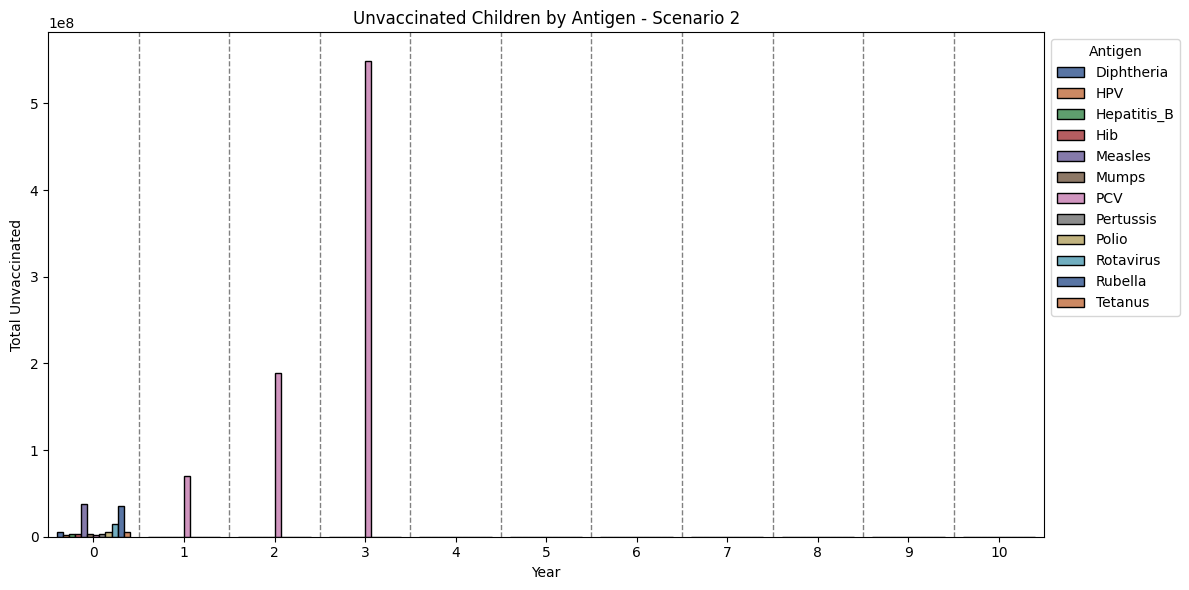

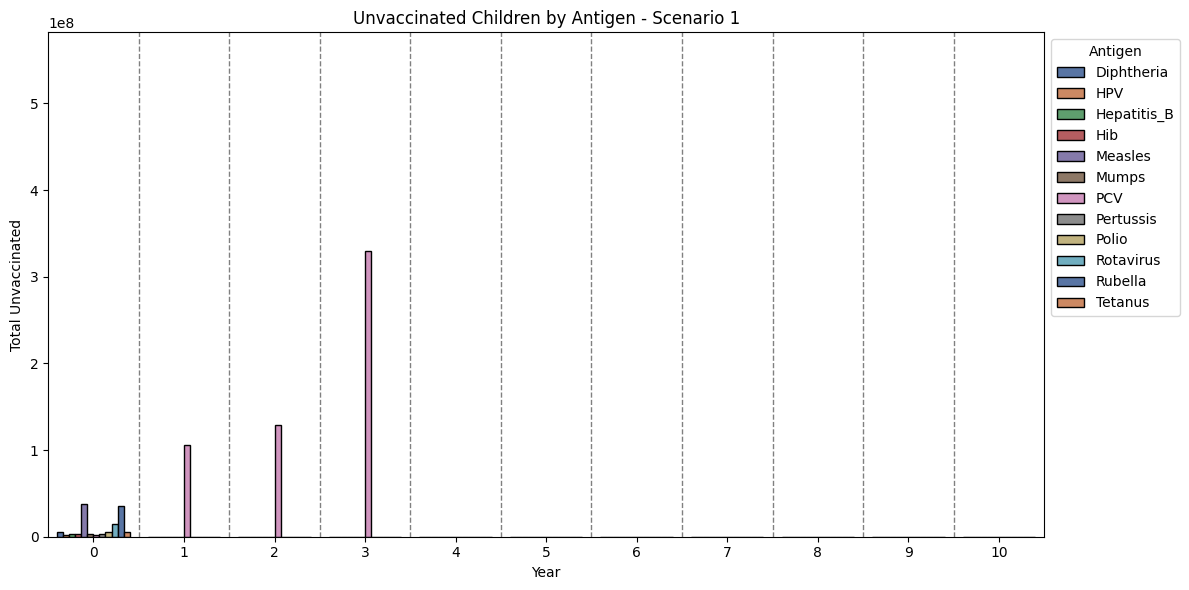

In [8]:
# iterates over all scenarios presented in the data
# Create a list of all years from 0 to 10
all_years = list(range(0, 11))

# Loop through each scenario and generate a separate plot
for scenario in df['Scenario'].unique():
    # Filter the DataFrame for the current scenario
    scenario_df = df[df['Scenario'] == scenario]

    # Grouping by Year and Antigen, and summing the Value column
    result = scenario_df.groupby(['Year', 'Antigen'])['Value'].sum().reset_index()
    result = result[result['Year'].between(0, 10)]

    # Filling missing combinations of Year and Antigen with 0.0 value
    result = result.pivot_table(index='Year', columns='Antigen', values='Value', fill_value=0.0).reset_index()

    # Melt the DataFrame to have a long format suitable for plotting
    result = pd.melt(result, id_vars='Year', var_name='Antigen', value_name='Value')

    # Set a color palette with distinct colors for each antigen
    palette = sns.color_palette("deep", n_colors=len(result['Antigen'].unique()))

    # Plotting the bar chart with seaborn
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Year', y='Value', hue='Antigen', data=result, palette=palette, edgecolor='black')  # Add edgecolor for boxes

    # Add vertical lines at each break between years (0 to 10)
    for year in all_years[1:]:
        plt.axvline(x=year - 0.5, color='gray', linestyle='--', linewidth=1)

    plt.xticks(range(len(all_years)), all_years)  # Set x-axis ticks for all years
    plt.ylim(0, df['Value'].max()+ (df['Value'].max()*0.05))
    plt.xlabel('Year')
    plt.ylabel('Total Unvaccinated')
    plt.title(f'Unvaccinated Children by Antigen - Scenario {scenario}')
    plt.legend(title='Antigen', bbox_to_anchor=(1, 1))
    plt.tight_layout()  # Adjust layout for better visualization
    plt.show()
